# Overview

Building makemore with bigram models.

# Data Loading and EDA

In [372]:
with open('names.txt', 'r') as file:
    names = file.read().splitlines()

In [373]:
names[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [374]:
len(names)

32033

In [375]:
min(len(name) for name in names)

2

In [376]:
max(len(name) for name in names)

15

In [377]:
import itertools

In [378]:
for name in names[:3]:
    for ch1, ch2 in itertools.pairwise(name):
        print(ch1, ch2)

e m
m m
m a
o l
l i
i v
v i
i a
a v
v a


In [379]:
b = {}
for name in names:
    chs = ['<S>'] + list(name) + ['<E>']
    for ch1, ch2 in itertools.pairwise(chs):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

In [380]:
b.items()

dict_items([(('<S>', 'e'), 1531), (('e', 'm'), 769), (('m', 'm'), 168), (('m', 'a'), 2590), (('a', '<E>'), 6640), (('<S>', 'o'), 394), (('o', 'l'), 619), (('l', 'i'), 2480), (('i', 'v'), 269), (('v', 'i'), 911), (('i', 'a'), 2445), (('<S>', 'a'), 4410), (('a', 'v'), 834), (('v', 'a'), 642), (('<S>', 'i'), 591), (('i', 's'), 1316), (('s', 'a'), 1201), (('a', 'b'), 541), (('b', 'e'), 655), (('e', 'l'), 3248), (('l', 'l'), 1345), (('l', 'a'), 2623), (('<S>', 's'), 2055), (('s', 'o'), 531), (('o', 'p'), 95), (('p', 'h'), 204), (('h', 'i'), 729), (('<S>', 'c'), 1542), (('c', 'h'), 664), (('h', 'a'), 2244), (('a', 'r'), 3264), (('r', 'l'), 413), (('l', 'o'), 692), (('o', 't'), 118), (('t', 't'), 374), (('t', 'e'), 716), (('e', '<E>'), 3983), (('<S>', 'm'), 2538), (('m', 'i'), 1256), (('a', 'm'), 1634), (('m', 'e'), 818), (('<S>', 'h'), 874), (('r', 'p'), 14), (('p', 'e'), 197), (('e', 'r'), 1958), (('r', '<E>'), 1377), (('e', 'v'), 463), (('v', 'e'), 568), (('l', 'y'), 1588), (('y', 'n'), 18

In [381]:
sorted(b.items(), key=lambda kv: kv[1], reverse=True)

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [382]:
import torch

In [383]:
N = torch.zeros((27, 27), dtype=torch.int32)

In [384]:
chars = sorted(set(''.join(names)))

s_to_i = {s:i + 1 for i, s in enumerate(chars)}
s_to_i['.'] = 0

i_to_s = {i + 1:s for i, s in enumerate(chars)}
i_to_s[0] = "."

In [385]:
for name in names:
    chs = ['.'] + list(name) + ['.']
    for ch1, ch2 in itertools.pairwise(chs):
        idx1, idx2 = s_to_i[ch1], s_to_i[ch2]
        N[idx1, idx2] += 1

In [386]:
import matplotlib.pyplot as plt

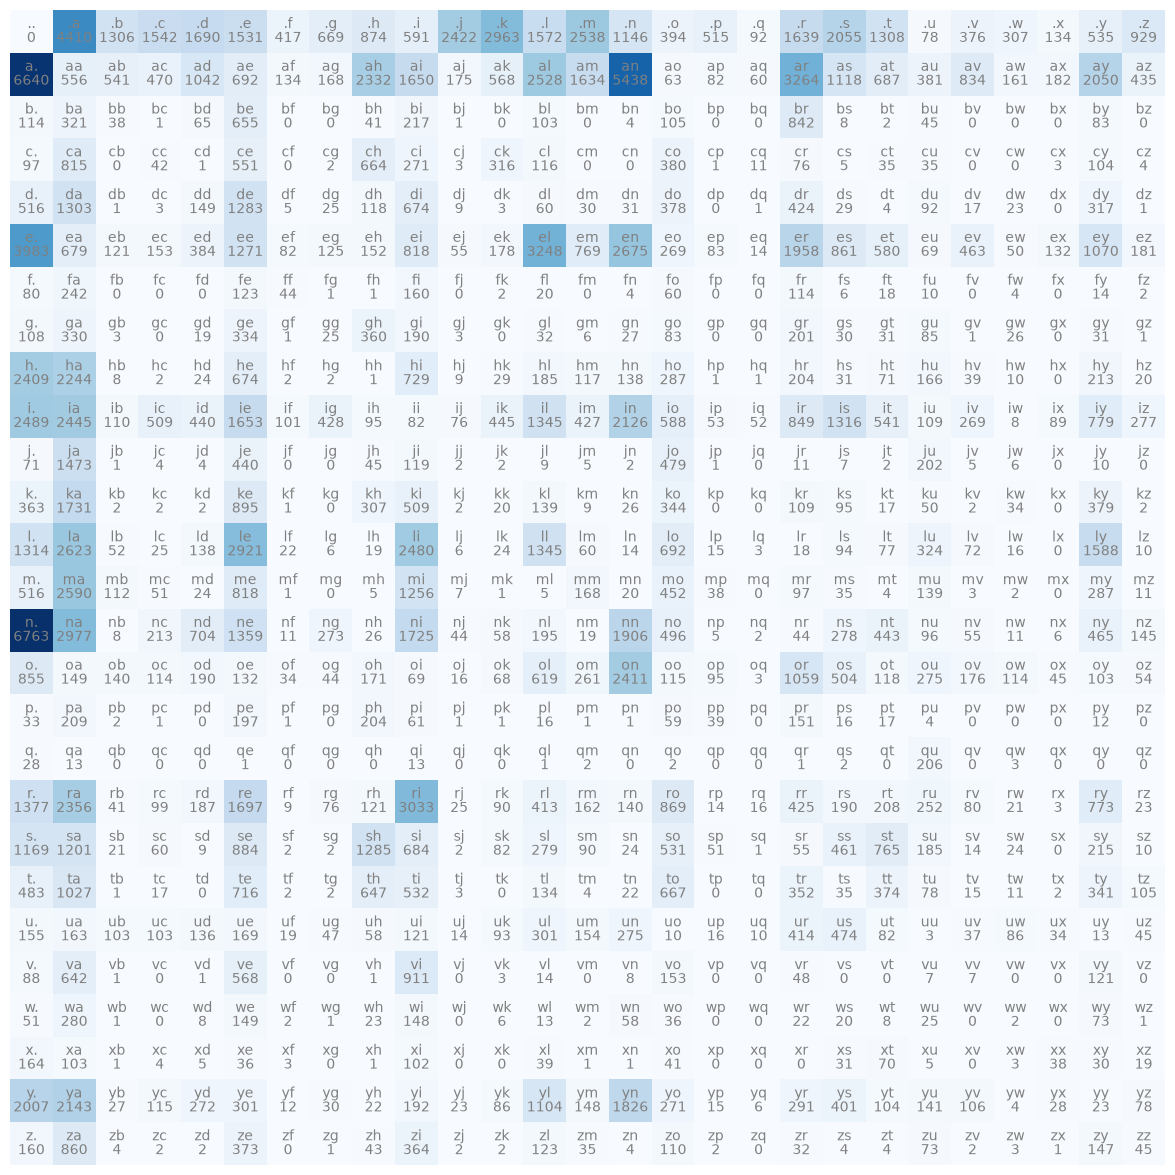

In [387]:
%matplotlib inline

plt.figure(figsize=(15, 15))
plt.imshow(N.numpy(), cmap="Blues")
for i in range(27):
    for j in range(27):
        chstr = i_to_s[i] + i_to_s[j]
        plt.text(j, i, chstr, ha='center', va='bottom', color='gray')
        plt.text(j, i, N[i, j].item(), ha='center', va='top', color='gray')
plt.axis('off');

# Table-Based Bigram Model

In [388]:
# Apply smoothing to prevent -infty
P = (N+1).float()
P /= P.sum(dim=1, keepdim=True)

In [389]:
g = torch.Generator().manual_seed(42)

def generate_name():
    new_name = ''

    idx = 0
    while True:
        p = P[idx]
        idx = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        # Special character is at index 0
        if idx == 0:
            break
        else:
            new_name += i_to_s[idx]

    return new_name

out = []
for _ in range(5):
    out.append(generate_name())

out

['anugeenvi', 's', 'mabidushan', 'stan', 'silaylelaremah']

In [390]:
nll = 0.0
n = 0
for name in names:
    chs = ['.'] + list(name) + ['.']
    for ch1, ch2 in itertools.pairwise(chs):
        idx1, idx2 = s_to_i[ch1], s_to_i[ch2]
        p = P[idx1, idx2]
        log_prob = torch.log(p)
        nll -= log_prob
        n += 1

print(f"Average negative log likelihood: {nll / n}")

Average negative log likelihood: 2.4543561935424805


# Neural Net-Based Bigram Model (End-to-End)

Steps:
1. Create dataset
2. Create simple neural net
3. Train with gradient descent
4. Sample from neural net to get names

The neural network here is just a linear layer (followed by softmax). With this setup, the best performance it can possibly achieve is that of the table-based model, so we should expect the model to converge to the performance of the table-based model with gradient descent.

In [391]:
with open('names.txt', 'r') as file:
    names = file.read().splitlines()

xs, ys = [], []
for name in names:
    chs = ['.'] + list(name) + ['.']
    for ch1, ch2 in itertools.pairwise(chs):
        idx1, idx2 = s_to_i[ch1], s_to_i[ch2]
        xs.append(idx1)
        ys.append(idx2)

xs, ys = torch.tensor(xs), torch.tensor(ys)

In [392]:
import torch.nn.functional as F

In [393]:
X_enc = F.one_hot(xs, num_classes=27).float()

In [394]:
g = torch.Generator().manual_seed(42)
W = torch.randn((27, 27), generator=g, requires_grad=True)

In [395]:
y_enc = F.one_hot(ys, num_classes=27).bool()

num_epochs = 200
for epoch in range(num_epochs):
    W.grad = None
    # Forward pass
    logits = X_enc @ W
    probs = logits.exp() / logits.exp().sum(dim=1, keepdims=True)
    # Compute loss
    loss = -probs[y_enc].log().mean()
    # Backward pass
    loss.backward()
    with torch.no_grad():
        W -= 50 * W.grad

    print(f"Epoch: {epoch + 1}, loss: {loss}")

Epoch: 1, loss: 3.696648120880127
Epoch: 2, loss: 3.365849256515503
Epoch: 3, loss: 3.1507301330566406
Epoch: 4, loss: 3.0080673694610596
Epoch: 5, loss: 2.9114675521850586
Epoch: 6, loss: 2.84065580368042
Epoch: 7, loss: 2.787369728088379
Epoch: 8, loss: 2.7464544773101807
Epoch: 9, loss: 2.714378595352173
Epoch: 10, loss: 2.6886606216430664
Epoch: 11, loss: 2.667574882507324
Epoch: 12, loss: 2.649940013885498
Epoch: 13, loss: 2.6349411010742188
Epoch: 14, loss: 2.622006416320801
Epoch: 15, loss: 2.610724687576294
Epoch: 16, loss: 2.6007909774780273
Epoch: 17, loss: 2.5919747352600098
Epoch: 18, loss: 2.5840957164764404
Epoch: 19, loss: 2.5770130157470703
Epoch: 20, loss: 2.5706119537353516
Epoch: 21, loss: 2.5647995471954346
Epoch: 22, loss: 2.5595009326934814
Epoch: 23, loss: 2.5546505451202393
Epoch: 24, loss: 2.5501961708068848
Epoch: 25, loss: 2.5460915565490723
Epoch: 26, loss: 2.5422985553741455
Epoch: 27, loss: 2.538783311843872
Epoch: 28, loss: 2.5355167388916016
Epoch: 29, l